In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import signal, sparse
from tqdm import tqdm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from joblib import Parallel, delayed
import os

In [3]:
# Limit thread usage to avoid over-parallelism crashes
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

def get_d_matrix(L):
    return sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L - 2))

def baseline_correction_als(y, lam=1e5, p=0.01, niter=10, D=None):
    L = len(y)
    if D is None:
        D = get_d_matrix(L)
    w = np.ones(L)
    for _ in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return y - z

def smoothing_savgol(y, window_length=7, polyorder=2):
    return signal.savgol_filter(y, window_length=window_length, polyorder=polyorder)

def normalize_tic(spectrum):
    tic = np.sum(spectrum)
    return spectrum / tic if tic > 0 else spectrum

def preprocess_spectrum(spectrum, D=None):
    y = baseline_correction_als(spectrum, D=D)
    y = smoothing_savgol(y)
    y = normalize_tic(y)
    return y

def preprocess_adata_to_array(adata, n_jobs=4, batch_size=1000):
    """Preprocess spectra and return as NumPy array suitable for next cell."""
    X = adata.X
    D = get_d_matrix(X.shape[1])
    all_processed = []

    for start in tqdm(range(0, adata.shape[0], batch_size), desc="Preprocessing (batched)"):
        end = min(start + batch_size, adata.shape[0])
        spectra = [
            X[i].toarray().flatten() if sparse.issparse(X) else X[i]
            for i in range(start, end)
        ]
        processed = Parallel(n_jobs=n_jobs, prefer="threads")(
            delayed(preprocess_spectrum)(spec, D=D) for spec in spectra
        )
        all_processed.append(np.vstack(processed))

    data = np.vstack(all_processed)
    return data

# === 2. PEAK DETECTION ===

def detect_peaks(spectrum, mz_axis, prominence=0.01, intensity_threshold=100):
    peaks, props = signal.find_peaks(spectrum, prominence=prominence)
    intensities = spectrum[peaks]
    valid = intensities >= intensity_threshold
    return mz_axis[peaks][valid], intensities[valid]

def ppm_diff(ref, target):
    return (target - ref) / ref * 1e6

def hybrid_tolerance_check(ref, target, ppm_tol=16.5, da_tol=0.02, cutoff_mz=2000):
    if ref < cutoff_mz:
        return abs(target - ref) <= da_tol
    return abs(ppm_diff(ref, target)) <= ppm_tol

# === 3. GLOBAL PEAK SELECTION ===

def find_top_peaks_global(adata, n_peaks=1000):
    all_peaks = []
    mz_axis = adata.var_names.astype(float).values
    X = adata.layers["preprocessed"] if "preprocessed" in adata.layers else adata.X

    for i in tqdm(range(adata.shape[0]), desc="Detecting peaks"):
        spectrum = X[i].toarray().flatten() if sparse.issparse(X) else X[i]
        mz_peaks, intensities = detect_peaks(spectrum, mz_axis)
        all_peaks.extend(zip(mz_peaks, intensities))

    all_peaks = np.array(all_peaks, dtype=[("mz", float), ("intensity", float)])
    sorted_peaks = np.sort(all_peaks, order="intensity")[::-1]

    selected = []
    for peak in sorted_peaks:
        if len(selected) >= n_peaks:
            break
        if all(not hybrid_tolerance_check(p["mz"], peak["mz"]) for p in selected):
            selected.append(peak)

    return np.sort(np.array([p["mz"] for p in selected]))

# === 4. PEAK AGGREGATION ===

def extract_and_aggregate_peaks(adata, selected_mz):
    mz_axis = adata.var_names.astype(float).values
    X = adata.layers["preprocessed"] if "preprocessed" in adata.layers else adata.X

    aggregated_intensities = []
    aggregated_mz_names = []

    for mz_ref in selected_mz:
        if mz_ref < MZ_CUTOFF_DA:
            delta = DA_TOLERANCE
            diff_array = np.abs(mz_axis - mz_ref)
        else:
            delta = PPM_TOLERANCE
            diff_array = np.abs((mz_axis - mz_ref) / mz_ref * 1e6)

        idx = np.where(diff_array <= delta)[0]
        if len(idx) == 0:
            summed = np.zeros((adata.shape[0],))
            avg_mz = mz_ref
        else:
            summed = X[:, idx].sum(axis=1)
            summed = np.asarray(summed).flatten()
            avg_mz = mz_axis[idx].mean()

        aggregated_intensities.append(summed)
        aggregated_mz_names.append(f"{avg_mz:.6f}")

    new_X = np.vstack(aggregated_intensities).T
    return ad.AnnData(X=new_X, obs=adata.obs.copy(), var=pd.DataFrame(index=aggregated_mz_names))

# === 5. VISUALIZATION & ANALYSIS ===

def plot_peak_distribution(adata, mz_idx, cmap="viridis"):
    intensity = adata.X[:, mz_idx]
    coords = adata.obs[["x", "y"]].values
    plt.figure(figsize=(6, 6))
    plt.scatter(coords[:, 0], coords[:, 1], c=intensity, cmap=cmap, s=5)
    plt.title(f"Peak index {mz_idx}")
    plt.xlabel("x"); plt.ylabel("y")
    plt.axis("equal"); plt.colorbar()
    plt.show()

def run_pca_clustering(adata, n_components=10, n_clusters=5):
    from sklearn.cluster import KMeans
    X = adata.X
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    kmeans = KMeans(n_clusters=n_clusters).fit(X_pca)
    adata.obs["cluster"] = kmeans.labels_.astype(str)
    return adata


In [4]:
# === PARAMETERS ===
PROMINENCE = 0.01
INTENSITY_THRESHOLD = 100.0
TOP_N_PEAKS = 1000
DA_TOLERANCE = 0.02
PPM_TOLERANCE = 16.5
MZ_CUTOFF_DA = 2000  # Use Da tolerance below this, ppm above this

input_file = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a.h5ad"
output_file = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a_peaks_010_1000_020_150_600_1000.h5ad"

In [5]:
adata = sc.read_h5ad(input_file)
print("Loaded:", input_file)

Loaded: /Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a.h5ad


/opt/anaconda3/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [6]:
data = preprocess_adata_to_array(adata, n_jobs=4)

Preprocessing (batched): 100%|██████████| 17/17 [1:02:36<00:00, 220.94s/it]


In [7]:
selected_mz = find_top_peaks_global(adata)


Detecting peaks: 100%|██████████| 16605/16605 [01:19<00:00, 208.28it/s]


In [8]:
adata_peaks = extract_and_aggregate_peaks(adata, selected_mz)

In [9]:
adata_peaks.write(output_file)
print("Saved to:", output_file)

Saved to: /Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a_peaks_010_1000_020_150_600_1000.h5ad


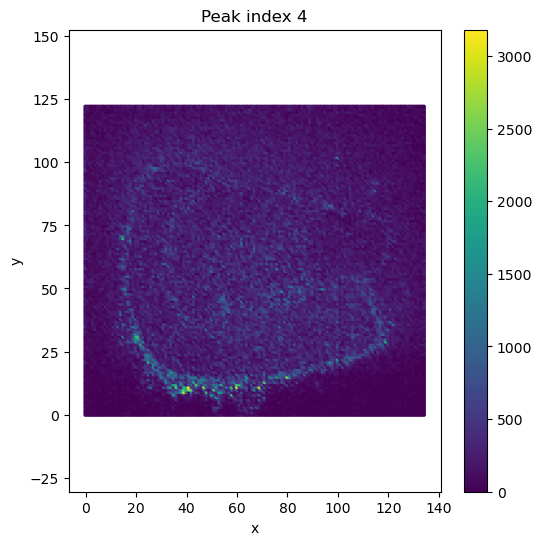

In [ ]:
plot_peak_distribution(adata_peaks, mz_idx=)

In [16]:
import plotly.graph_objects as go
import numpy as np

def plot_top_peaks_stem(adata, title="Top 1000 Peaks by Max Intensity (Stem Plot)"):
    # Get m/z values
    mz_axis = adata.var_names.astype(float).values

    # Get max intensity per m/z (not sum)
    if hasattr(adata.X, "toarray"):  # sparse
        max_intensity = np.asarray(adata.X.max(axis=0)).ravel()
    else:  # dense
        max_intensity = np.max(adata.X, axis=0)

    # Find top 1000 peaks by max intensity
    top_indices = np.argsort(max_intensity)[::-1][:1000]
    mz_top = mz_axis[top_indices]
    intensity_top = max_intensity[top_indices]

    # Sort m/z values for cleaner appearance
    sorted_order = np.argsort(mz_top)
    mz_top = mz_top[sorted_order]
    intensity_top = intensity_top[sorted_order]

    # Create stem plot (vertical lines + markers)
    fig = go.Figure()

    # Vertical lines (stems)
    for x, y in zip(mz_top, intensity_top):
        fig.add_trace(go.Scatter(
            x=[x, x],
            y=[0, y],
            mode='lines',
            line=dict(color='crimson', width=1),
            showlegend=False,
            hoverinfo='skip'
        ))

    # Markers (dots at the top of each stem)
    fig.add_trace(go.Scatter(
        x=mz_top,
        y=intensity_top,
        mode='markers',
        marker=dict(size=4, color='crimson'),
        hovertemplate='Avg m/z: %{x:.4f}<br>Max Intensity: %{y:.2f}',
        name='Max Intensity'
    ))

    fig.update_layout(
        title=title,
        xaxis_title="Averaged m/z",
        yaxis_title="Max Intensity (across sample)",
        template="plotly_white",
        dragmode="zoom",
        hovermode="closest"
    )

    fig.show()

In [17]:
plot_top_peaks_stem(adata_peaks)

In [22]:
import numpy as np
import pandas as pd

def top_peaks_csv(adata, csv_path):

    mz_axis = adata.var_names.astype(float).values

    # Get max intensity per m/z (not sum)
    if hasattr(adata.X, "toarray"):  # sparse
        max_intensity = np.asarray(adata.X.max(axis=0)).ravel()
    else:  # dense
        max_intensity = np.max(adata.X, axis=0)

    # Find top 1000 peaks by max intensity
    top_indices = np.argsort(max_intensity)[::-1][:1000]
    mz_top = mz_axis[top_indices]
    intensity_top = max_intensity[top_indices]

    # Sort m/z values for cleaner appearance
    sorted_order = np.argsort(mz_top)
    mz_top = mz_top[sorted_order]
    intensity_top = intensity_top[sorted_order]

    # 3. Create a DataFrame
    df = pd.DataFrame({
        "m/z": mz_top,
        "max_intensity": intensity_top
    })

    # 4. Save to CSV
    df.to_csv(csv_path, index=False)


In [23]:
csv_path = "/Users/amin/Desktop/PhD_Thesis/Code/IMZML Tools/a_peaks_010_1000_020_150_600_1000.csv"
top_peaks_csv(adata_peaks, csv_path)